#### **Hierarchical Clustering**

##### **What is hierarchical clustering?**

Hierarchical clustering is a method of clustering (grouping similar data points) that builds a tree-like structure of clusters, called a dendrogram. Instead of giving you just one fixed set of clusters, it shows how clusters are formed step by step at different levels of similarity.
Any type of clustering always is a part of Unsupervised Learning. 

It groups data based on similarity, forming a hierarchy:. At the bottom, every data point is its own cluster. As you move up, similar clusters merge. At the top, all points belong to one big cluster

Two main types :

- Agglomerative (bottom-up) – most common
    - Start with each point as its own cluster
    - Repeatedly merge the closest clusters

- Divisive (top-down)
    - Start with all data in one cluster
    - Repeatedly split clusters


**Steps :**

1) Iterate over data
    - for i in range (len(Data))
        - for j in range (i+1, len(data))
2) Using distance formula check data closest to the current data. 
    - Explanation 
        - Euclidian (ID1, ID2) --> Output 1
        - Euclidian (ID1, ID3) --> Output 2
        - Euclidian (ID1, ID4) --> Output 3
    - Get minimum of Ouput 1, output 2, output 3. 
    - You get an ID that can be merged with say ID3
3) Merge the closest data with current data & save them as cluster. 
    - You now have a new cluster which has ID1 and ID3 together. 
    - The new cluster value will now change to be mean of individuals. i.e. X1 will be mean of id1 and id3 . X2 will be mean of ID1 and ID3 and so on. 
    - The new definitions of cluster will now be compared for other IDs. 
4) Repeat above steps. 




The distance used above can be found using three ways:
- Euclidian
- Manhattan
- Cosine


In K means clustering we have a parameter of K, we donot have any such parameter to tune here in hierarchical clustering. 

Why was hierarchical clustering needed?

Traditional clustering methods (like K-means) have limitations:

Problems with earlier methods

You must choose the number of clusters beforehand

They give only one final grouping

No insight into relationships between clusters

What hierarchical clustering solves

✔ No need to pre-specify number of clusters
✔ Reveals multi-level structure in data
✔ Shows how clusters relate to each other
✔ More interpretable (via dendrograms)

In short:
It was needed to understand data structure, not just assign labels.

**How it works (high level)**

1) Compute distances between all data points

2) Merge the closest clusters

3) Update distances (using linkage methods like:
    - single (nearest neighbour)
    - complete (Farthest neigbour)
    - average
    - Ward’s method

4) Repeat until one cluster remains

##### **When should you use it?**

Use hierarchical clustering when:
- You don’t know the number of clusters
- You want interpretability
- Dataset is small to medium sized
- Relationships between clusters matter

Avoid it when:
- Dataset is very large (computationally expensive)

##### **Hierarchical Clustering Practical**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [2]:
df = pd.read_csv("data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### Plot Dendrogram for Hierarchical Clustering

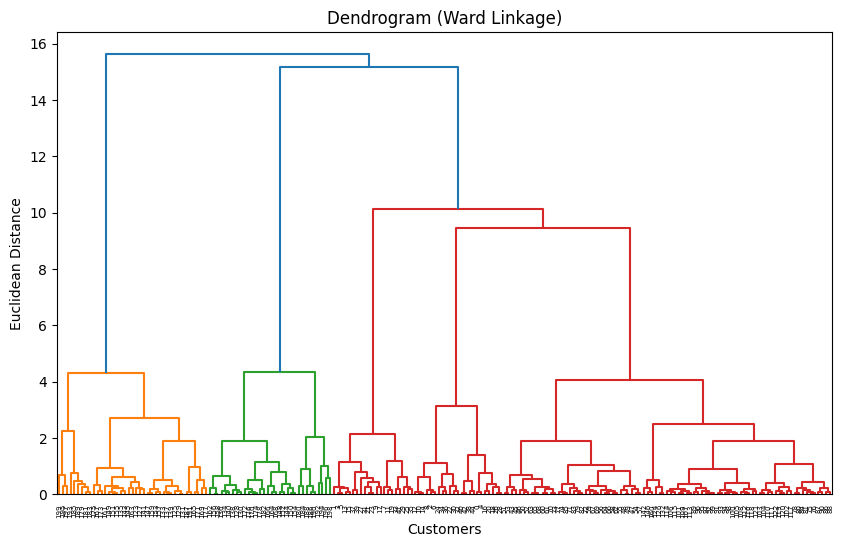

In [6]:
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()


In [7]:
hc = AgglomerativeClustering(
    n_clusters=5, ## No of clusters needed basis what yoiu see ..could be 3 or 5 here
    metric='euclidean',
    linkage='ward'
)

labels_hc = hc.fit_predict(X_scaled)


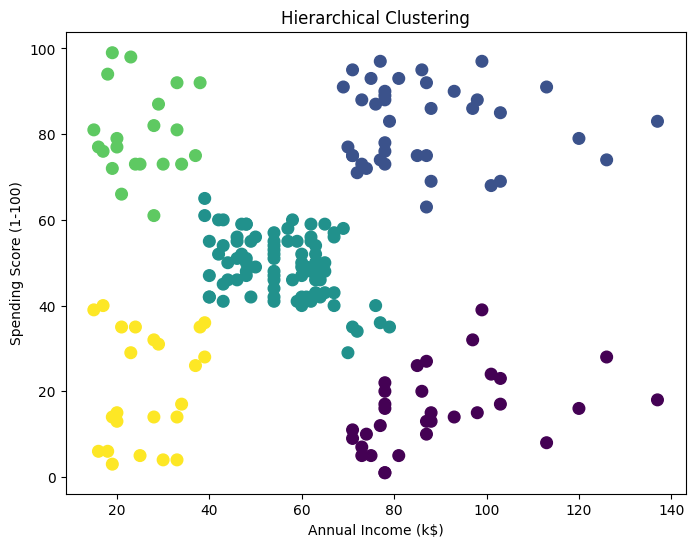

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_hc,
    s=70
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()
